In [ ]:
!pip install ucimlrepo

## Logistic Regression

Logistic Regression is a simple linear model used for binary classification. It estimates the probability of a sample belonging to the positive class using a logistic function. In this notebook, it is applied with preprocessing that scales numerical features and one-hot encodes categorical features, ensuring the model handles imbalanced classes with class weights.

              precision    recall  f1-score   support

           0       0.95      0.86      0.90      2084
           1       0.49      0.74      0.59       382

    accuracy                           0.84      2466
   macro avg       0.72      0.80      0.75      2466
weighted avg       0.88      0.84      0.85      2466



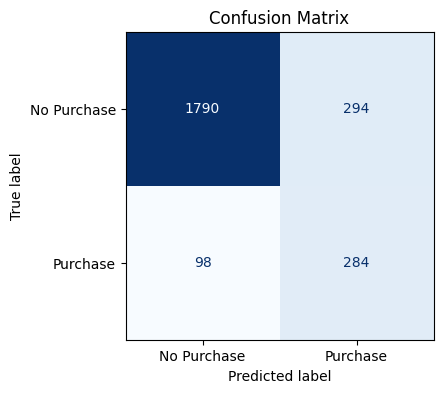

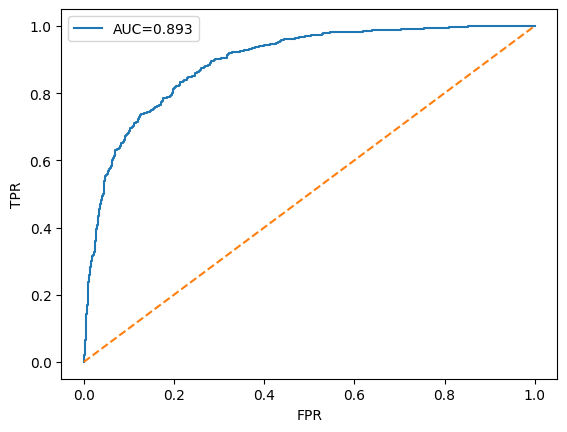

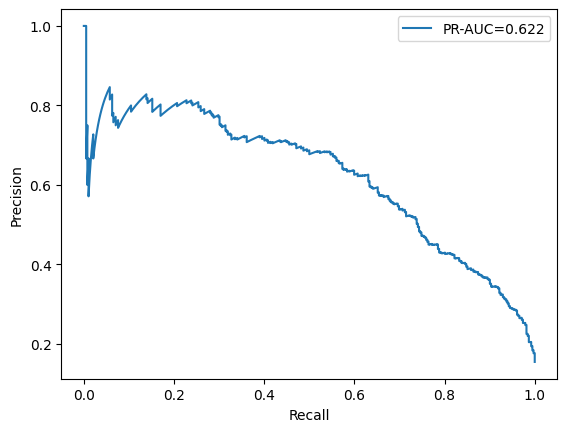

In [ ]:
import pandas as pd
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

d = fetch_ucirepo(id=468)
X = d.data.features
y = LabelEncoder().fit_transform(d.data.targets['Revenue'])

num = ['Administrative','Administrative_Duration','Informational','Informational_Duration',
       'ProductRelated','ProductRelated_Duration','BounceRates','ExitRates','PageValues','SpecialDay']
cat = ['Month','OperatingSystems','Browser','Region','TrafficType','VisitorType','Weekend']

pre = ColumnTransformer([
    ('n', StandardScaler(), num),
    ('c', OneHotEncoder(handle_unknown='ignore'), cat)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42, stratify=y)

pipe = Pipeline([
    ('p', pre),
    ('m', LogisticRegression(class_weight='balanced', max_iter=1000))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Purchase','Purchase'])
plt.figure(figsize=(4,4))
disp.plot(cmap='Blues', ax=plt.gca(), colorbar=False)
plt.title('Confusion Matrix')
plt.show()

y_proba = pipe.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC={roc_auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.show()

prec, rec, _ = precision_recall_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

plt.plot(rec, prec, label=f'PR-AUC={pr_auc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()


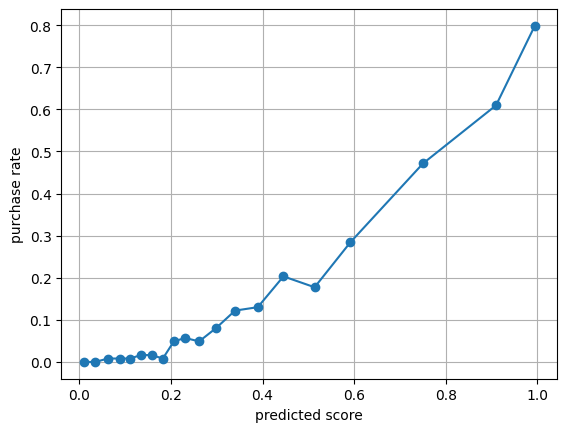

In [ ]:
scores = pipe.predict_proba(X_test)[:, 1]
df = pd.DataFrame({"score": scores, "label": y_test})
df["bin"] = pd.qcut(df["score"], 20, duplicates="drop")

agg = (
    df.groupby("bin", observed=True)
      .agg(score_mean=("score","mean"),
           purchase_rate=("label","mean"))
      .reset_index()
      .sort_values("score_mean")
)

plt.plot(agg["score_mean"], agg["purchase_rate"], marker="o")
plt.xlabel("predicted score")
plt.ylabel("purchase rate")
plt.grid()
plt.show()

## Random forest

Random Forest is an ensemble model that builds multiple decision trees and averages their predictions. It is robust to overfitting and can handle both numerical and categorical data. In this notebook, we configured it with 300 trees, a minimum leaf size of 2, logarithmic feature selection, and class balancing to improve performance on the minority class.

Accuracy: 0.8921330089213301
              precision    recall  f1-score   support

           0       0.94      0.93      0.94      2084
           1       0.65      0.66      0.66       382

    accuracy                           0.89      2466
   macro avg       0.79      0.80      0.80      2466
weighted avg       0.89      0.89      0.89      2466



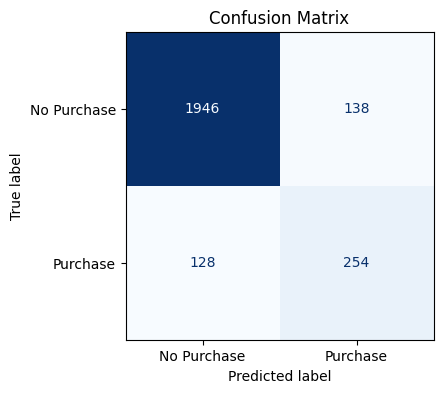

ROC-AUC: 0.920
PR-AUC: 0.710
Cohen’s Kappa: 0.592


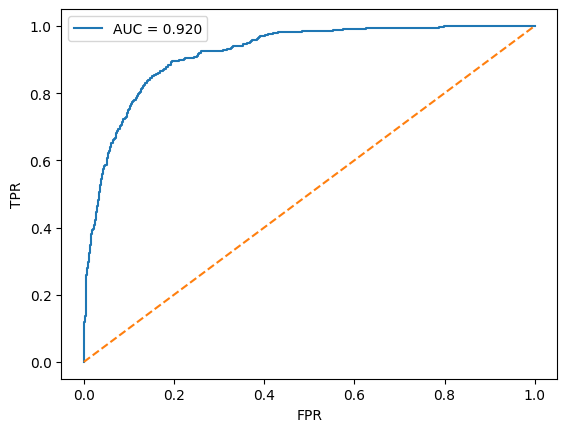

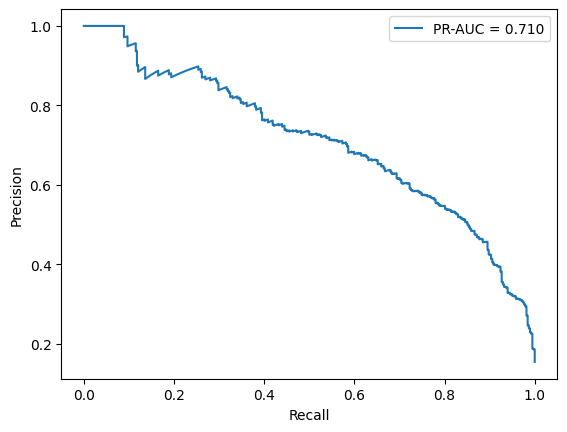

In [ ]:
import pandas as pd
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score, average_precision_score,
    cohen_kappa_score, precision_recall_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

d = fetch_ucirepo(id=468)
X = d.data.features
y = LabelEncoder().fit_transform(d.data.targets['Revenue'])

num = ['Administrative','Administrative_Duration','Informational','Informational_Duration',
       'ProductRelated','ProductRelated_Duration','BounceRates','ExitRates','PageValues','SpecialDay']
cat = ['Month','OperatingSystems','Browser','Region','TrafficType','VisitorType','Weekend']

pre = ColumnTransformer([
    ('n', StandardScaler(), num),
    ('c', OneHotEncoder(handle_unknown='ignore'), cat)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42, stratify=y)

pipe = Pipeline([
    ('p', pre),
    ('m', RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        max_features='log2',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Purchase','Purchase'])
plt.figure(figsize=(4,4))
disp.plot(cmap='Blues', ax=plt.gca(), colorbar=False)
plt.title('Confusion Matrix')
plt.show()

y_proba = pipe.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)
kappa = cohen_kappa_score(y_test, y_pred)

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")
print(f"Cohen’s Kappa: {kappa:.3f}")

fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.show()

prec, rec, _ = precision_recall_curve(y_test, y_proba)
plt.plot(rec, prec, label=f'PR-AUC = {pr_auc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()


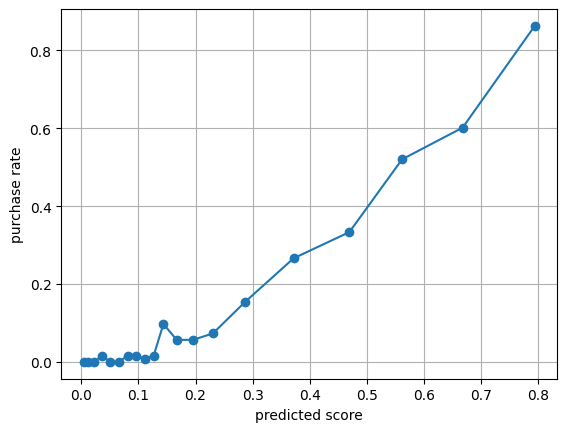

In [ ]:
scores = pipe.predict_proba(X_test)[:, 1]
df = pd.DataFrame({"score": scores, "label": y_test})
df["bin"] = pd.qcut(df["score"], 20, duplicates="drop")

agg = (
    df.groupby("bin", observed=True)
      .agg(score_mean=("score","mean"),
           purchase_rate=("label","mean"))
      .reset_index()
      .sort_values("score_mean")
)

plt.plot(agg["score_mean"], agg["purchase_rate"], marker="o")
plt.xlabel("predicted score")
plt.ylabel("purchase rate")
plt.grid()
plt.show()

## Multilayer Perception

The 5-Layer Multilayer Perceptron (MLP) is a fully connected neural network with three hidden layers of sizes 64 → 32 → 16, each followed by ReLU activation and dropout for regularization. The network outputs a single value representing the logit for binary classification. This model is trained with a weighted binary cross-entropy loss to account for the imbalanced dataset.

Epoch 1, Loss 0.9676
Epoch 2, Loss 0.7210
Epoch 3, Loss 0.6728
Epoch 4, Loss 0.6494
Epoch 5, Loss 0.6316
Epoch 6, Loss 0.6211
Epoch 7, Loss 0.6084
Epoch 8, Loss 0.5939
Epoch 9, Loss 0.5869
Epoch 10, Loss 0.5925
Epoch 11, Loss 0.5750
Epoch 12, Loss 0.5784
Epoch 13, Loss 0.5573
Epoch 14, Loss 0.5527
Epoch 15, Loss 0.5473
Epoch 16, Loss 0.5369
Epoch 17, Loss 0.5249
Epoch 18, Loss 0.5323
Epoch 19, Loss 0.5335
Epoch 20, Loss 0.5145
              precision    recall  f1-score   support

         0.0       0.96      0.85      0.90      2084
         1.0       0.51      0.83      0.63       382

    accuracy                           0.85      2466
   macro avg       0.73      0.84      0.77      2466
weighted avg       0.89      0.85      0.86      2466



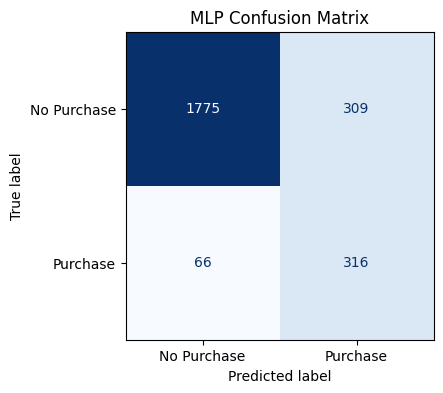

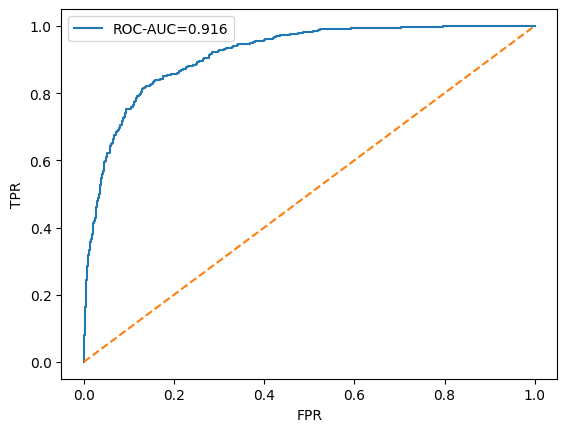

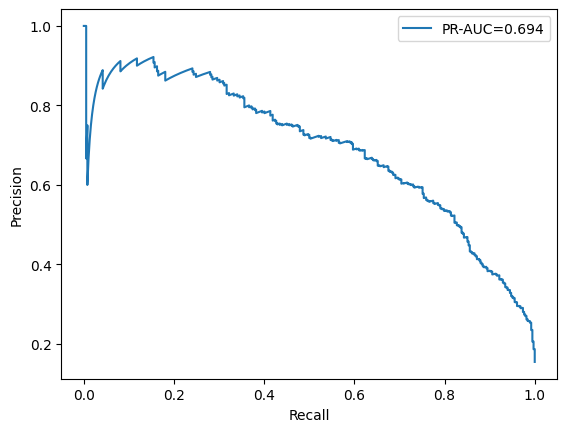

In [ ]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

d = fetch_ucirepo(id=468)
X = d.data.features
y = LabelEncoder().fit_transform(d.data.targets['Revenue'])

num = ['Administrative','Administrative_Duration','Informational','Informational_Duration',
       'ProductRelated','ProductRelated_Duration','BounceRates','ExitRates','PageValues','SpecialDay']
cat = ['Month','OperatingSystems','Browser','Region','TrafficType','VisitorType','Weekend']

pre = ColumnTransformer([
    ('n', StandardScaler(), num),
    ('c', OneHotEncoder(handle_unknown='ignore'), cat)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42, stratify=y)

X_train = pre.fit_transform(X_train).toarray()
X_test = pre.transform(X_test).toarray()
input_dim = X_train.shape[1]

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64)

class MLP(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.l1 = nn.Linear(n,64)
        self.l2 = nn.Linear(64,32)
        self.l3 = nn.Linear(32,16)
        self.o = nn.Linear(16,1)
        self.r = nn.ReLU()
        self.d = nn.Dropout(.3)
    def forward(self,x):
        x=self.d(self.r(self.l1(x)))
        x=self.d(self.r(self.l2(x)))
        x=self.d(self.r(self.l3(x)))
        return self.o(x)

model = MLP(input_dim)
pos_w = torch.tensor([ (y_train==0).sum() / (y_train==1).sum() ], dtype=torch.float32)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_w)
opt = optim.Adam(model.parameters(), lr=1e-3)

for e in range(20):
    tot=0
    for xb,yb in train_loader:
        opt.zero_grad()
        out=model(xb)
        loss=loss_fn(out,yb)
        loss.backward()
        opt.step()
        tot+=loss.item()
    print(f'Epoch {e+1}, Loss {tot/len(train_loader):.4f}')

model.eval()
p=[]
proba=[]
l=[]
with torch.no_grad():
    for xb,yb in test_loader:
        out=torch.sigmoid(model(xb))
        proba.extend(out.numpy())
        p.extend(torch.round(out).numpy())
        l.extend(yb.numpy())

p=np.array(p)
proba=np.array(proba)
l=np.array(l)

print(classification_report(l,p))

cm=confusion_matrix(l,p)
plt.figure(figsize=(4,4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Purchase','Purchase']).plot(
    cmap='Blues', ax=plt.gca(), colorbar=False
)
plt.title('MLP Confusion Matrix')
plt.show()

fpr, tpr, _ = roc_curve(l, proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'ROC-AUC={roc_auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.show()

prec, rec, _ = precision_recall_curve(l, proba)
pr_auc = average_precision_score(l, proba)
plt.plot(rec, prec, label=f'PR-AUC={pr_auc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()


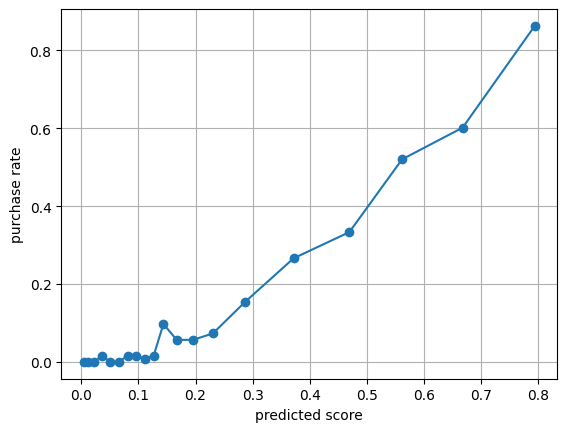

In [ ]:
_, X_test, _, y_test = train_test_split(X, y, test_size=.2, random_state=42, stratify=y)
scores = pipe.predict_proba(X_test)[:, 1]
df = pd.DataFrame({"score": scores, "label": y_test})
df["bin"] = pd.qcut(df["score"], 20, duplicates="drop")

agg = (
    df.groupby("bin", observed=True)
      .agg(score_mean=("score","mean"),
           purchase_rate=("label","mean"))
      .reset_index()
      .sort_values("score_mean")
)

plt.plot(agg["score_mean"], agg["purchase_rate"], marker="o")
plt.xlabel("predicted score")
plt.ylabel("purchase rate")
plt.grid()
plt.show()

## Visualization

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

d = fetch_ucirepo(id=468)
df = d.data.features.copy()
df['Revenue'] = d.data.targets['Revenue']

def heatmap(data=df):
    numeric = data.select_dtypes(include='number')
    plt.figure(figsize=(10,8))
    sns.heatmap(numeric.corr(), annot=True, fmt=".2f", cmap="coolwarm")
    plt.show()

def barchart(col):
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='Revenue', data=df, palette=['red','blue'])
    plt.ylabel('Count')
    plt.title(f'{col} Distribution by Purchase')
    plt.show()

def boxchart(col):
    q = df[col].quantile([0.025, 0.975])
    data = df[df[col].between(q[0.025], q[0.975])]
    plt.figure(figsize=(10,8))
    sns.boxplot(x='Revenue', y=col, data=data, palette=['red','blue'], hue='Revenue', width=0.4, fliersize=3)
    plt.title(f'{col} by Purchase')
    plt.show()

def scatterplot(x_col, y_col):
    xq = df[x_col].quantile([0.025, 0.975])
    yq = df[y_col].quantile([0.025, 0.975])
    data = df[df[x_col].between(xq[0.025], xq[0.975]) & df[y_col].between(yq[0.025], yq[0.975])]
    plt.figure(figsize=(10,8))
    sns.scatterplot(x=data[x_col], y=data[y_col], hue=data['Revenue'], palette=['red','blue'], s=75, alpha=0.7)
    plt.title(f'{x_col} vs {y_col}')
    plt.show()


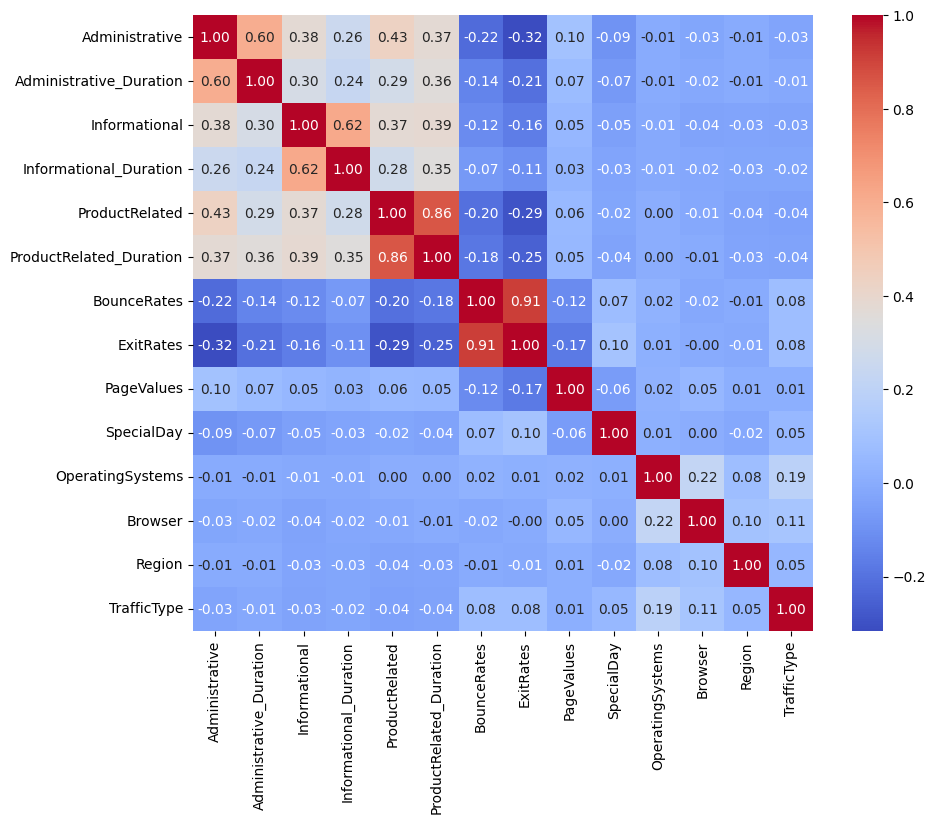

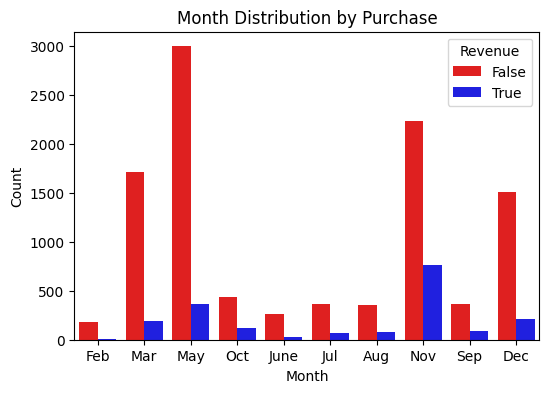

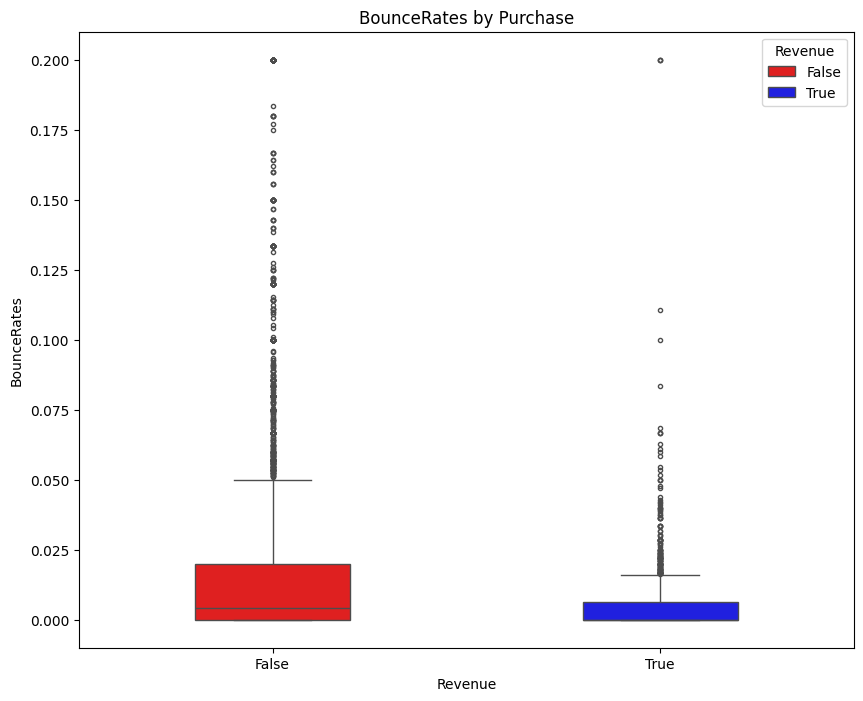

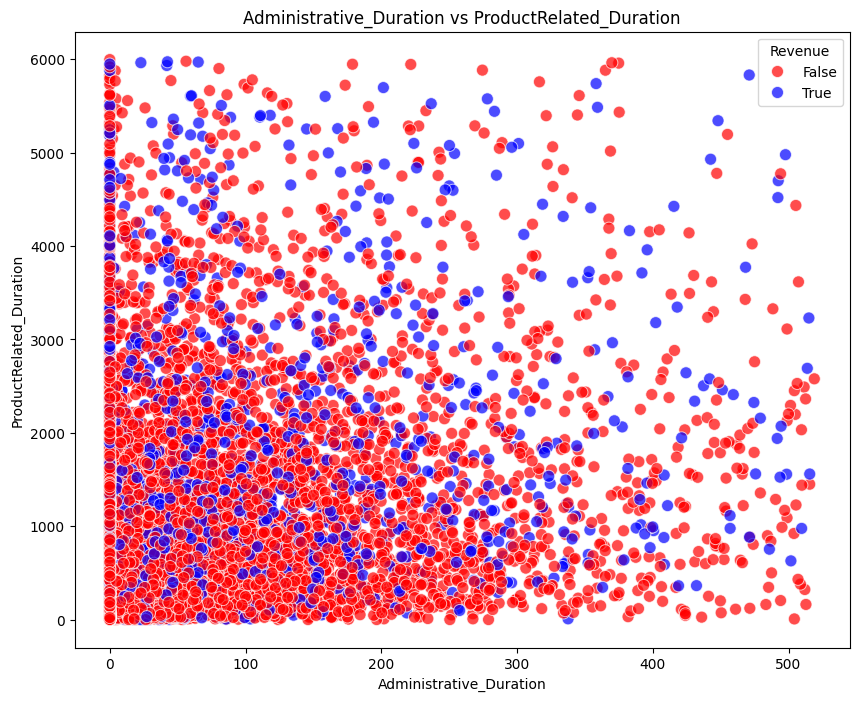

In [ ]:
# Cell 2: Playground

heatmap()
barchart('Month')
boxchart('BounceRates')
scatterplot('Administrative_Duration', 'ProductRelated_Duration')


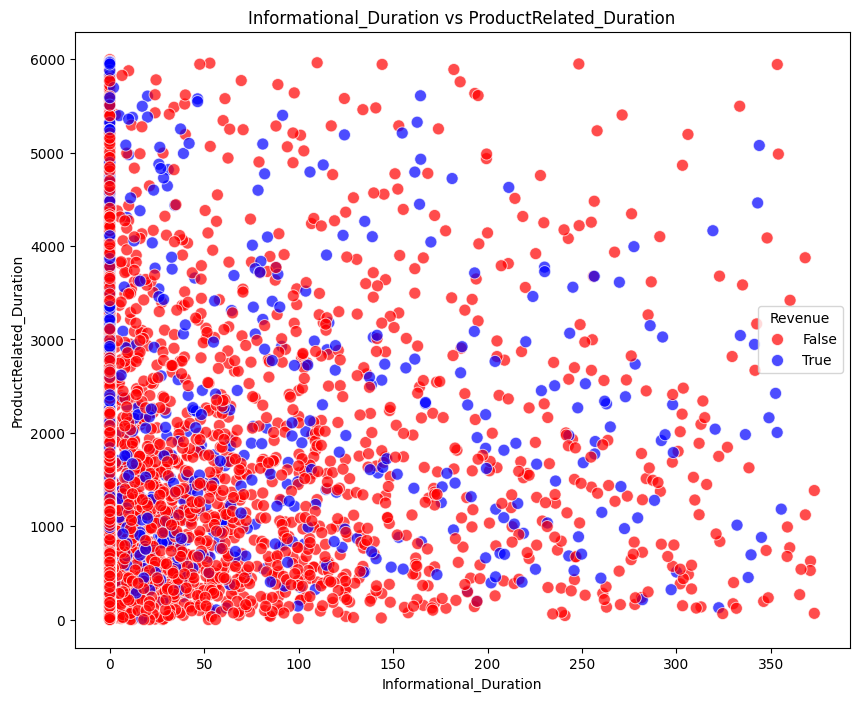

In [ ]:
scatterplot('Informational_Duration', 'ProductRelated_Duration')

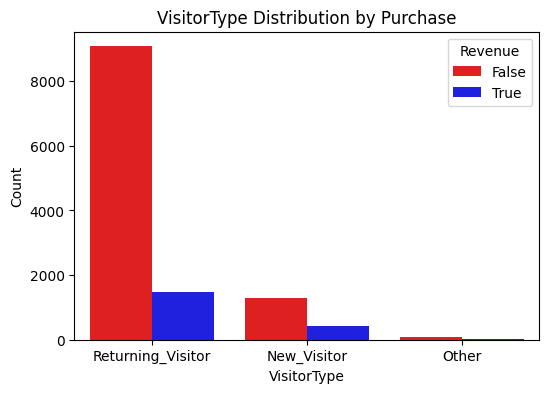

In [ ]:
barchart('VisitorType')

## Utils

In [ ]:
# scores = pipe.predict_proba(X_test)[:, 1]
# df = pd.DataFrame({"score": scores, "label": y_test})
# df["bin"] = pd.qcut(df["score"], 20, duplicates="drop")

# agg = (
#     df.groupby("bin", observed=True)
#       .agg(score_mean=("score","mean"),
#            purchase_rate=("label","mean"))
#       .reset_index()
#       .sort_values("score_mean")
# )

# plt.plot(agg["score_mean"], agg["purchase_rate"], marker="o")
# plt.xlabel("predicted score")
# plt.ylabel("purchase rate")
# plt.grid()
# plt.show()

Here is a polished, technically correct version that keeps your meaning but clarifies logic and terminology:

---

After plotting predicted purchase probability against the actual observed purchase rate across score bins, we observed two plateau regions around 0.35–0.45 and 0.55–0.65. A plateau indicates that the model assigns different predicted scores to users who ultimately have very similar purchasing behavior. In other words, within these ranges the model is not effectively separating users by true purchase intention—its probability estimates vary, but the underlying behavior does not. In contrast, regions with a steeper slope indicate that changes in the predicted score correspond to meaningful differences in actual purchase rates, suggesting stronger alignment between the model’s output and real user behavior.

Based on these observations, we use the centers of the two plateau regions as decision boundaries for segmenting user purchase intention. This yields three intention tiers: 0–0.40 as low intention, 0.40–0.60 as mid intention, and 0.60–1.00 as high intention. For low-intention users, the appropriate strategy is limited outreach (occasional ads or small discounts) primarily for general brand exposure. Mid-intention users represent uncertain or hesitant buyers, and thus benefit from personalized ads and more substantial promotional incentives. High-intention users are likely to purchase regardless, so only light-touch messaging and minimal discounting are recommended to control costs while maintaining engagement.
